In [4]:
import torch

torch.triu(torch.ones(3,3), diagonal=1).bool()

tensor([[False,  True,  True],
        [False, False,  True],
        [False, False, False]])

# 在 MovieLens 100K 上训练 TwoTower 召回模型

本 notebook 展示如何利用现有的 `TwoTower`、`InfoNCE`、`models.py / loss_function.py` 等组件，
在 MovieLens 100K 数据集上完成一个完整的召回模型训练流程。

## 整体思路

> **TwoTower（双塔模型）** 是工业界主流召回架构：
> - 用户侧特征 → UserTower → `u_emb`（L2归一化向量）
> - 物品侧特征 → ItemTower → `i_emb`（L2归一化向量）
> - 训练目标：让正样本对的点积得分高于随机其他物品 → **InfoNCE Loss**
> - 离线评估：预计算全量物品嵌入，ANN 检索 Top-K

## 与现有 `RecommenderTrainer` 的接口差异

| 维度 | `RecommenderTrainer` 期望 | TwoTower 原始接口 |
|------|--------------------------|-----------------|
| `model(X)` 签名 | `model(X)` → `(B,)` logit | `model(user_feat, item_feat)` → `(u_emb, i_emb)` |
| 损失 | BCEWithLogitsLoss | InfoNCE（in-batch 负采样）|
| 数据集输出 | 整数 ID + 标签 | 稠密特征向量 |

本教程将展示**两种方案**：
1. **手动训练循环**（推荐）：直接使用 TwoTower + InfoNCE，最符合双塔训练逻辑
2. **接入 RecommenderTrainer**：添加 Embedding 层封装，使其满足现有 Trainer 接口

## 第一节：环境准备与数据下载

In [1]:
import os, sys
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# 将项目根目录加入 sys.path，方便 import 本地模块
sys.path.insert(0, os.path.abspath('.'))

# 优先使用 GPU / Apple MPS / CPU
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f"使用设备: {device}")

DATA_DIR = "./datasets/ml-100k/ml-100k"  # 解压后的数据目录

# 确认关键文件存在
for fname in ['u.data', 'u.user', 'u.item']:
    path = os.path.join(DATA_DIR, fname)
    exists = "✅" if os.path.exists(path) else "❌"
    print(f"{exists} {path}")

使用设备: mps
✅ ./datasets/ml-100k/ml-100k/u.data
✅ ./datasets/ml-100k/ml-100k/u.user
✅ ./datasets/ml-100k/ml-100k/u.item


## 第二节：数据加载与特征工程

### 用户特征
- `age`：连续值，直接归一化
- `gender`：M/F → 二值编码
- `occupation`：21 种职业 → Label Encoding（整数）

### 物品特征
- `genres`：19 种体裁，每部电影可属于多种 → **multi-hot 向量**，直接作为物品侧特征

> ⚠️ 本节手动构建特征矩阵（而非复用 `MovieLens100KDataset`），是因为 TwoTower
> 需要将 **用户特征** 和 **物品特征分开传入两个独立的 Tower**，而现有 Dataset 类
> 将所有特征拼成一个 X 矩阵，更适合 FM / DeepFM 等联合交叉模型。

In [4]:
# ── 1. 加载原始数据 ──────────────────────────────────────────────
ratings = pd.read_csv(
    os.path.join(DATA_DIR, 'u.data'),
    sep='\t', names=['user_id', 'movie_id', 'rating', 'timestamp']
)

# u.user: user_id | age | gender | occupation | zip_code
users = pd.read_csv(
    os.path.join(DATA_DIR, 'u.user'),
    sep='|', names=['user_id', 'age', 'gender', 'occupation', 'zip_code']
)

# u.item: movie_id | title | release_date | video_date | IMDB_url | 19个体裁列
genre_cols = ['unknown','Action','Adventure','Animation','Childrens','Comedy',
              'Crime','Documentary','Drama','Fantasy','Film-Noir','Horror',
              'Musical','Mystery','Romance','Sci-Fi','Thriller','War','Western']
item_col_names = ['movie_id', 'title', 'release_date', 'video_date', 'IMDB_url'] + genre_cols
items = pd.read_csv(
    os.path.join(DATA_DIR, 'u.item'),
    sep='|', names=item_col_names, encoding='latin-1'
)

print(f"评分数: {len(ratings):,}  用户数: {users['user_id'].nunique()}  电影数: {items['movie_id'].nunique()}")

# ── 2. 构建用户特征矩阵 ───────────────────────────────────────────
#   特征：age（归一化）, gender（0/1）, occupation（整数编码）
le_occ = LabelEncoder()
users['occ_enc'] = le_occ.fit_transform(users['occupation'])
users['gender_enc'] = (users['gender'] == 'M').astype(np.float32)
users['age_norm'] = (users['age'] - users['age'].mean()) / users['age'].std()

# 最终用户特征：[age_norm, gender_enc, occ_enc]，shape (num_users, 3)
user_feat_cols = ['age_norm', 'gender_enc', 'occ_enc']
user_feat_df = users.set_index('user_id')[user_feat_cols].astype(np.float32)

# ── 3. 构建物品特征矩阵 ───────────────────────────────────────────
#   特征：19 维体裁 multi-hot 向量，shape (num_items, 19)
item_feat_df = items.set_index('movie_id')[genre_cols].astype(np.float32)

user_dim = len(user_feat_cols)       # 3
item_dim = len(genre_cols)           # 19
print(f"\nuser_dim = {user_dim}")
print(f"item_dim = {item_dim}")
print(f"\n用户特征示例 (user_id=1):\n{user_feat_df.loc[5].to_dict()}")
print(f"\n物品特征示例 (movie_id=1):\n{item_feat_df.loc[5].to_dict()}")

评分数: 100,000  用户数: 943  电影数: 1682

user_dim = 3
item_dim = 19

用户特征示例 (user_id=1):
{'age_norm': -0.08627772331237793, 'gender_enc': 0.0, 'occ_enc': 13.0}

物品特征示例 (movie_id=1):
{'unknown': 0.0, 'Action': 0.0, 'Adventure': 0.0, 'Animation': 0.0, 'Childrens': 0.0, 'Comedy': 0.0, 'Crime': 1.0, 'Documentary': 0.0, 'Drama': 1.0, 'Fantasy': 0.0, 'Film-Noir': 0.0, 'Horror': 0.0, 'Musical': 0.0, 'Mystery': 0.0, 'Romance': 0.0, 'Sci-Fi': 0.0, 'Thriller': 1.0, 'War': 0.0, 'Western': 0.0}


## 第三节：构建 TwoTowerDataset

TwoTower 训练使用**正样本对** (user_id, item_id)，负样本通过 **In-Batch** 机制自动产生（不需要显式采样）：

- `__getitem__` 只返回正样本对对应的用户/物品特征向量
- 每个 batch 内的 $N$ 条正样本形成 $N \times N$ 的相似度矩阵，对角线为正样本，其余 $N(N-1)$ 个为负样本

**划分策略（留一法 / LOO）**：每位用户按时间戳排序，取最后一次交互作为测试集，其余作为训练集。

In [5]:
class TwoTowerDataset(Dataset):
    """
    TwoTower 正样本对数据集。
    
    返回字典：
      'user' : shape (user_dim,)  用户特征向量
      'item' : shape (item_dim,)  物品特征向量
      'user_id' / 'item_id' : 用于推理时索引（评估阶段需要）
    """
    def __init__(self, interactions: pd.DataFrame,
                 user_feat_df: pd.DataFrame,
                 item_feat_df: pd.DataFrame):
        # 只保留特征表中存在的 user/item
        valid_users = interactions['user_id'].isin(user_feat_df.index)
        valid_items = interactions['movie_id'].isin(item_feat_df.index)
        self.interactions = interactions[valid_users & valid_items].reset_index(drop=True)
        self.user_feat = user_feat_df
        self.item_feat = item_feat_df

    def __len__(self):
        return len(self.interactions)

    def __getitem__(self, idx):
        row = self.interactions.iloc[idx]
        user_id = int(row['user_id'])
        item_id = int(row['movie_id'])
        return {
            'user'    : torch.tensor(self.user_feat.loc[user_id].values, dtype=torch.float32),
            'item'    : torch.tensor(self.item_feat.loc[item_id].values,  dtype=torch.float32),
            'user_id' : user_id,
            'item_id' : item_id,
        }


# ── 留一法数据划分 ────────────────────────────────────────────────
ratings_sorted = ratings.sort_values('timestamp')
# 每位用户时间戳最大的一条作为测试集
test_idx = ratings_sorted.groupby('user_id')['timestamp'].idxmax()
test_df  = ratings_sorted.loc[test_idx].copy()
train_df = ratings_sorted.drop(test_idx).copy()

# 只取正样本（rating >= 4）训练，鼓励模型区分高评分物品
train_pos = train_df[train_df['rating'] >= 4]
test_pos  = test_df[test_df['rating'] >= 4]

train_dataset = TwoTowerDataset(train_pos, user_feat_df, item_feat_df)
test_dataset  = TwoTowerDataset(test_pos,  user_feat_df, item_feat_df)

print(f"训练正样本对: {len(train_dataset):,}")
print(f"测试正样本对: {len(test_dataset):,}")

# 验证 __getitem__ 输出结构
sample = train_dataset[0]
print(f"\ndataset[0] keys: {list(sample.keys())}")
print(f"  user 特征形状: {sample['user'].shape}")
print(f"  item 特征形状: {sample['item'].shape}")

训练正样本对: 54,898
测试正样本对: 477

dataset[0] keys: ['user', 'item', 'user_id', 'item_id']
  user 特征形状: torch.Size([3])
  item 特征形状: torch.Size([19])


## 第四节：初始化 TwoTower 模型

```
用户特征 (B, user_dim=3)
       ↓
  UserTower: Linear→ReLU→BN → ... → Linear → L2Norm
       ↓
  u_emb  (B, embed_dim=64)  ─┐
                              ├─ dot(u, i) / τ → logits (B, B)
  i_emb  (B, embed_dim=64)  ─┘
       ↑
  ItemTower: Linear→ReLU→BN → ... → Linear → L2Norm
       ↑
物品特征 (B, item_dim=19)
```

`temperature`（τ）是可学习参数，初始化为 0.07（参考 CLIP 设计），
控制相似度分布的"尖锐程度"——值越小分布越集中，正负样本区分越明显。

In [ ]:
from RQVAE import TwoTower

model = TwoTower(
    user_dim    = user_dim,        # 3  (age + gender + occupation)
    item_dim    = item_dim,        # 19 (体裁 multi-hot)
    hidden_dims = [256, 128],      # 两个隐层
    embed_dim   = 64               # 最终嵌入维度
).to(device)

print(model)
print(f"\n可学习温度初始值: {model.temperature.item():.4f}")

# 快速验证 forward 输出形状
dummy_user = torch.randn(4, user_dim).to(device)
dummy_item = torch.randn(4, item_dim).to(device)
u_emb, i_emb = model(dummy_user, dummy_item)
print(f"\nu_emb 形状: {u_emb.shape}  → (batch, embed_dim)")
print(f"i_emb 形状: {i_emb.shape}  → (batch, embed_dim)")
print(f"L2 范数（应≈1）: u={u_emb.norm(dim=-1).mean():.4f}, i={i_emb.norm(dim=-1).mean():.4f}")

TwoTower(
  (UserTower): Tower(
    (net): Sequential(
      (0): Linear(in_features=3, out_features=256, bias=True)
      (1): ReLU()
      (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): Linear(in_features=256, out_features=128, bias=True)
      (4): ReLU()
      (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): Linear(in_features=128, out_features=64, bias=True)
    )
  )
  (ItemTower): Tower(
    (net): Sequential(
      (0): Linear(in_features=19, out_features=256, bias=True)
      (1): ReLU()
      (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): Linear(in_features=256, out_features=128, bias=True)
      (4): ReLU()
      (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): Linear(in_features=128, out_features=64, bias=True)
    )
  )
)

可学习温度初始值: 0.0700

u_emb 形状: torch.Size([4, 64])  → (batch,

## 第五节：配置 InfoNCE 损失与优化器

**In-Batch InfoNCE** 公式（symmetric）：

$$\mathcal{L} = -\frac{1}{2N}\sum_{i=1}^{N}\left[\log\frac{e^{s(u_i,v_i)/\tau}}{\sum_j e^{s(u_i,v_j)/\tau}} + \log\frac{e^{s(v_j,u_j)/\tau}}{\sum_j e^{s(v_j,u_i)/\tau}}\right]$$

其中 $s(u,v) = u \cdot v$（因为已做 L2 归一化，等价于余弦相似度），$\tau$ 为可学习温度参数。

> **注意**：`temperature` 是 `nn.Parameter`，已自动包含在 `model.parameters()` 中，
> 无需单独将其加入优化器参数组。

In [7]:
from loss_funciton import InfoNCE

# Adam 优化器，temperature 作为 nn.Parameter 自动包含在 model.parameters() 中
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# 验证 temperature 在参数组中
param_names = [name for name, _ in model.named_parameters()]
print("模型所有参数名：")
for n in param_names:
    print(f"  {n}")

# 演示一个 mini-batch 的 InfoNCE 计算
dummy_u = torch.randn(8, 64)  # 已做 L2 归一化的 u_emb
dummy_i = torch.randn(8, 64)
dummy_u = F.normalize(dummy_u, dim=-1)
dummy_i = F.normalize(dummy_i, dim=-1)
tau = torch.tensor(0.07)
loss_val = InfoNCE(dummy_u, dummy_i, tau)
print(f"\n演示 InfoNCE loss（batch_size=8）: {loss_val.item():.4f}")
print(f"理论最大值（完全随机）≈ log(batch_size) = {np.log(8):.4f}")

模型所有参数名：
  temperature
  UserTower.net.0.weight
  UserTower.net.0.bias
  UserTower.net.2.weight
  UserTower.net.2.bias
  UserTower.net.3.weight
  UserTower.net.3.bias
  UserTower.net.5.weight
  UserTower.net.5.bias
  UserTower.net.6.weight
  UserTower.net.6.bias
  ItemTower.net.0.weight
  ItemTower.net.0.bias
  ItemTower.net.2.weight
  ItemTower.net.2.bias
  ItemTower.net.3.weight
  ItemTower.net.3.bias
  ItemTower.net.5.weight
  ItemTower.net.5.bias
  ItemTower.net.6.weight
  ItemTower.net.6.bias

演示 InfoNCE loss（batch_size=8）: 3.1604
理论最大值（完全随机）≈ log(batch_size) = 2.0794


## 第六节：训练循环与 In-Batch 负采样

**In-Batch 负采样工作原理：**

对于 batch 大小为 $N$ 的数据：
1. `model(user_feat, item_feat)` → `u_emb (N, 64)`, `i_emb (N, 64)`
2. `logits = u_emb @ i_emb.T / τ`，得到 $(N, N)$ 的相似度矩阵
3. 对角线 `logits[i, i]` = 第 $i$ 个用户与其正样本物品的得分（正样本）
4. 非对角线 `logits[i, j] (i≠j)` = 第 $i$ 个用户与 batch 内其他物品的得分（负样本）
5. 用行/列 cross-entropy（对角线为 label）引导模型拉大正负样本距离

> ⚠️ In-Batch 负采样的 batch_size 越大，每个正样本对应的负样本越多，训练信号越丰富，
> 但显存消耗也越大。推荐 batch_size=512~2048。

Epoch  0 | Loss: 6.2860 | τ (temperature): 0.1157
Epoch  1 | Loss: 6.2105 | τ (temperature): 0.1323
Epoch  2 | Loss: 6.2034 | τ (temperature): 0.1450
Epoch  3 | Loss: 6.2000 | τ (temperature): 0.1572
Epoch  4 | Loss: 6.1942 | τ (temperature): 0.1665
Epoch  5 | Loss: 6.1916 | τ (temperature): 0.1733
Epoch  6 | Loss: 6.1901 | τ (temperature): 0.1813
Epoch  7 | Loss: 6.1865 | τ (temperature): 0.1866
Epoch  8 | Loss: 6.1863 | τ (temperature): 0.1946
Epoch  9 | Loss: 6.1855 | τ (temperature): 0.2023
Epoch 10 | Loss: 6.1839 | τ (temperature): 0.2100
Epoch 11 | Loss: 6.1822 | τ (temperature): 0.2152
Epoch 12 | Loss: 6.1788 | τ (temperature): 0.2186
Epoch 13 | Loss: 6.1800 | τ (temperature): 0.2244
Epoch 14 | Loss: 6.1780 | τ (temperature): 0.2289
Epoch 15 | Loss: 6.1776 | τ (temperature): 0.2342
Epoch 16 | Loss: 6.1750 | τ (temperature): 0.2375
Epoch 17 | Loss: 6.1750 | τ (temperature): 0.2422
Epoch 18 | Loss: 6.1733 | τ (temperature): 0.2482
Epoch 19 | Loss: 6.1716 | τ (temperature): 0.2489


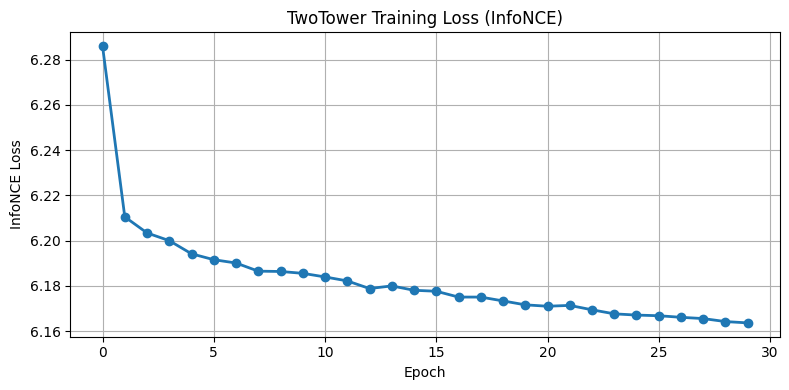

In [8]:
os.makedirs('./model', exist_ok=True)

EPOCHS     = 30
BATCH_SIZE = 512
NUM_WORKERS = 0       # macOS 多进程 DataLoader 需设为 0，避免 fork 死锁
PATIENCE   = 5        # Early Stopping：连续 N epoch 无提升则停止

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS
)

epoch_losses = []
best_loss = float('inf')
no_improve = 0

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    for batch in train_loader:
        user_feat = batch['user'].to(device)  # (B, user_dim)
        item_feat = batch['item'].to(device)  # (B, item_dim)

        optimizer.zero_grad()

        # TwoTower forward：返回 L2 归一化的嵌入向量
        u_emb, i_emb = model(user_feat, item_feat)

        # InfoNCE loss（in-batch 负采样）
        # model.temperature 是 nn.Parameter，直接传入（也可乘以一个 clamp 限制范围）
        loss = InfoNCE(u_emb, i_emb, model.temperature)

        loss.backward()

        # 梯度裁剪，防止梯度爆炸（与 RecommenderTrainer 保持一致）
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    epoch_losses.append(avg_loss)
    tau_val = model.temperature.item()

    print(f"Epoch {epoch:2d} | Loss: {avg_loss:.4f} | τ (temperature): {tau_val:.4f}")

    # Early Stopping & 保存最优模型
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), './model/best_model.pth')
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"Early Stopping @ Epoch {epoch}")
            break

# 绘制 Loss 曲线
plt.figure(figsize=(8, 4))
plt.plot(epoch_losses, marker='o', linewidth=2)
plt.title('TwoTower Training Loss (InfoNCE)')
plt.xlabel('Epoch')
plt.ylabel('InfoNCE Loss')
plt.grid(True)
plt.tight_layout()
plt.show()

## 第七节：模型评估：HR@K 与 NDCG@K

评估协议（**100-item 候选集**，与学术界标准一致）：

对每位测试用户：
1. 取其 1 条正样本物品
2. 随机采样 99 条他未交互的物品作为负样本
3. 对 100 个候选物品计算 `user_emb · item_emb` 得分并排序
4. 统计正样本排名 $rank_u$

$$HR@K = \frac{1}{|U|}\sum_{u}\mathbb{1}[rank_u \leq K]$$

$$NDCG@K = \frac{1}{|U|}\sum_{u}\frac{\mathbb{1}[rank_u \leq K]}{\log_2(rank_u+1)}$$

In [9]:
def evaluate_twotower(model, test_df, ratings_full,
                      user_feat_df, item_feat_df,
                      device, k=10, num_neg=99):
    """
    TwoTower 离线评估：HR@K 与 NDCG@K（100-item 候选集协议）。

    流程：
      1. 预计算全量物品嵌入（item gallery）
      2. 对每位测试用户：随机采样 num_neg 个未交互物品 + 1 个正样本物品
      3. user_emb · item_emb → 排序 → 统计正样本排名
    """
    model.eval()
    all_item_ids = item_feat_df.index.tolist()

    # 构建全量物品 ID → 已交互集合（用于负采样排除）
    user_inter_set = ratings_full.groupby('user_id')['movie_id'].apply(set).to_dict()

    # ───── 预计算全量物品嵌入 ─────────────────────────────────────
    item_feats_all = torch.tensor(
        item_feat_df.loc[all_item_ids].values, dtype=torch.float32
    ).to(device)                               # (num_items, item_dim)

    with torch.inference_mode():
        item_embs_all = model.ItemTower(item_feats_all)  # (num_items, embed_dim)

    item_id_to_idx = {iid: idx for idx, iid in enumerate(all_item_ids)}

    hrs, ndcgs = [], []

    with torch.inference_mode():
        for _, row in test_df.iterrows():
            uid      = int(row['user_id'])
            pos_iid  = int(row['movie_id'])

            # 跳过特征表中不存在的用户或物品
            if uid not in user_feat_df.index or pos_iid not in item_id_to_idx:
                continue

            interacted = user_inter_set.get(uid, set())

            # 随机采样 num_neg 条负样本
            neg_pool = [i for i in all_item_ids
                        if i not in interacted and i != pos_iid]
            if len(neg_pool) < num_neg:
                continue
            neg_iids = np.random.choice(neg_pool, size=num_neg, replace=False).tolist()
            candidate_iids = [pos_iid] + neg_iids          # 正样本始终在第 0 位

            # ── 用户嵌入 ──
            user_feat = torch.tensor(
                user_feat_df.loc[uid].values, dtype=torch.float32
            ).unsqueeze(0).to(device)                       # (1, user_dim)
            u_emb = model.UserTower(user_feat)              # (1, embed_dim)

            # ── 候选物品嵌入（从预计算的全量嵌入中索引）──
            cand_indices = [item_id_to_idx[i] for i in candidate_iids]
            cand_embs = item_embs_all[cand_indices]         # (100, embed_dim)

            # ── 计算得分并排名 ──
            scores = model.similarity(u_emb.expand_as(cand_embs), cand_embs)  # (100,)
            pos_score = scores[0].item()
            rank = int((scores > pos_score).sum().item()) + 1  # 从 1 开始

            hr   = 1.0 if rank <= k else 0.0
            ndcg = (1.0 / np.log2(rank + 1)) if rank <= k else 0.0
            hrs.append(hr)
            ndcgs.append(ndcg)

    return np.mean(hrs), np.mean(ndcgs)


# ── 加载最优权重并评估 ─────────────────────────────────────────────
model.load_state_dict(torch.load('./model/best_model.pth', map_location=device))

hr10, ndcg10 = evaluate_twotower(
    model, test_pos, ratings,
    user_feat_df, item_feat_df,
    device, k=10, num_neg=99
)

print(f"HR@10   = {hr10:.4f}")
print(f"NDCG@10 = {ndcg10:.4f}")

HR@10   = 0.1698
NDCG@10 = 0.0743


## 第八节：加载最优模型进行 Top-K 推理

TwoTower 推理分两阶段（与工业落地方式完全一致）：

1. **离线阶段**：对全量物品调用 `ItemTower` 预计算 `item_embs` 并存入向量数据库（如 Faiss）
2. **在线阶段**：给定新用户特征调用 `UserTower` 得到 `user_emb`，ANN 近邻检索 Top-K

本示例用 `torch.topk` 模拟 ANN（全量暴力检索），适合小规模数据。

In [10]:
# ── 加载最优权重 ──────────────────────────────────────────────────
model.load_state_dict(torch.load('./model/best_model.pth', map_location=device))
model.eval()

# ── Step 1: 离线预计算全量物品嵌入（item gallery）────────────────
all_item_ids = item_feat_df.index.tolist()
item_feats_tensor = torch.tensor(
    item_feat_df.loc[all_item_ids].values, dtype=torch.float32
).to(device)

with torch.inference_mode():
    item_emb_gallery = model.ItemTower(item_feats_tensor)  # (num_items, 64)

print(f"全量物品嵌入形状: {item_emb_gallery.shape}")

# ── Step 2: 在线推理：给定一个用户，召回 Top-10 ───────────────────
TARGET_USER_ID = 196    # 选一个测试用户（可自行更改）
TOP_K = 10

user_feat_vec = torch.tensor(
    user_feat_df.loc[TARGET_USER_ID].values, dtype=torch.float32
).unsqueeze(0).to(device)                                  # (1, user_dim)

with torch.inference_mode():
    user_emb = model.UserTower(user_feat_vec)              # (1, 64)

# 点积得分：user_emb 广播与全量 item_embs 相乘
scores = model.similarity(
    user_emb.expand_as(item_emb_gallery),
    item_emb_gallery
)                                                          # (num_items,)

# TopK 检索
topk_scores, topk_indices = torch.topk(scores, k=TOP_K)
topk_item_ids = [all_item_ids[i] for i in topk_indices.cpu().tolist()]

# ── 打印推荐结果 ──────────────────────────────────────────────────
print(f"\n用户 {TARGET_USER_ID} 的特征: {user_feat_df.loc[TARGET_USER_ID].to_dict()}")
print(f"\nTop-{TOP_K} 推荐电影：")
title_map = items.set_index('movie_id')['title'].to_dict()
for rank_i, (iid, score) in enumerate(zip(topk_item_ids, topk_scores.cpu().tolist()), 1):
    title = title_map.get(iid, 'Unknown')
    print(f"  {rank_i:2d}. [{iid:4d}] {title:<45s}  score={score:.4f}")

全量物品嵌入形状: torch.Size([1682, 64])

用户 196 的特征: {'age_norm': 1.2259786128997803, 'gender_enc': 1.0, 'occ_enc': 20.0}

Top-10 推荐电影：
   1. [ 653] Touch of Evil (1958)                           score=0.3276
   2. [ 656] M (1931)                                       score=0.3276
   3. [ 823] Mulholland Falls (1996)                        score=0.3276
   4. [1604] He Walked by Night (1948)                      score=0.3276
   5. [ 484] Maltese Falcon, The (1941)                     score=0.2953
   6. [ 525] Big Sleep, The (1946)                          score=0.2953
   7. [ 654] Chinatown (1974)                               score=0.2730
   8. [1313] Palmetto (1998)                                score=0.2730
   9. [ 855] Diva (1981)                                    score=0.2552
  10. [ 331] Edge, The (1997)                               score=0.2448


## 附录：如何将 TwoTower 接入现有 RecommenderTrainer（可选）

如果想复用 `RecommenderTrainer`（内置 Early Stopping / 评估 / 模型保存），
需要满足其接口约定：**`model(X)` → 标量 logit**。

**解决方案**：写一个 `TwoTowerRec` 封装类：
- 内置 `nn.Embedding` 层（用户/物品 ID → 嵌入向量）
- `forward(X)` 中拆开 `X[:,0]=user_id`, `X[:,1]=item_id`，分别查表后传入两个 Tower
- 返回点积相似度（标量 logit） → 配合 `BCEWithLogitsLoss`

> 注意：这种方式使用**逐点 BCE + 静态/动态负采样**，而非 InfoNCE。
> 效果通常比 InfoNCE 稍弱，但能直接复用现有配套工具（评估、Early Stopping 等）。

In [ ]:
from RQVAE import TwoTower
from dataset import MovieLens100KCFDataset
from trainer import RecommenderTrainer

class TwoTowerRec(nn.Module):
    """
    将 TwoTower 包装为 RecommenderTrainer 兼容的推荐模型。

    接口约定（与 Trainer 一致）：
      forward(X) 接受 shape=(B, 2) 的整数张量
        X[:,0] = encoded_user_id（来自 MovieLens100KCFDataset）
        X[:,1] = encoded_item_id
      返回 shape=(B,) 的点积相似度（logit）

    内部结构：
      user_id → UserEmbedding(embed_dim) → UserTower → u_emb（L2归一化）
      item_id → ItemEmbedding(embed_dim) → ItemTower → i_emb（L2归一化）
      output  = sum(u_emb * i_emb, dim=-1)  / temperature
    """
    def __init__(self, num_users: int, num_items: int,
                 embed_dim: int = 32,
                 hidden_dims: list = [64, 32],
                 out_dim: int = 16):
        super().__init__()
        # padding_idx=0：ID 编码从 1 开始，0 保留为 padding（与 MovieLens100KCFDataset 一致）
        self.user_emb = nn.Embedding(num_users + 1, embed_dim, padding_idx=0)
        self.item_emb = nn.Embedding(num_items + 1, embed_dim, padding_idx=0)
        self.two_tower = TwoTower(
            user_dim=embed_dim, item_dim=embed_dim,
            hidden_dims=hidden_dims, embed_dim=out_dim
        )

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        """
        Args:
            X: (B, 2) 整数张量，[:,0]=user_id, [:,1]=item_id
        Returns:
            logits: (B,) 点积相似度 / temperature
        """
        user_ids = X[:, 0]   # (B,)
        item_ids = X[:, 1]   # (B,)

        u_feat = self.user_emb(user_ids)   # (B, embed_dim)
        i_feat = self.item_emb(item_ids)   # (B, embed_dim)

        u_emb, i_emb = self.two_tower(u_feat, i_feat)   # 均已 L2 归一化

        # 点积 / 温度 → logit（标量），供 BCEWithLogitsLoss 使用
        logit = self.two_tower.similarity(u_emb, i_emb) / self.two_tower.temperature
        return logit   # (B,)


# ── 构建 Dataset（整数 ID 格式，与 Trainer 兼容）─────────────────
dataset = MovieLens100KCFDataset(
    data_path     = DATA_DIR,
    split_mode    = 'LOO',
    num_negatives = 4,          # 每条正样本静态采样 4 条负样本
    num_test_negatives = 99,
    dynamic_negative   = False
)

# 从 feature_encoder 获取类别数（编码从 1 开始，故 num_classes = len(classes_)）
num_users = len(dataset.feature_encoder['user_id'].classes_)
num_items = len(dataset.feature_encoder['movie_id'].classes_)
print(f"num_users={num_users}, num_items={num_items}")

# ── 初始化模型、优化器、Trainer ───────────────────────────────────
model_rec = TwoTowerRec(num_users=num_users, num_items=num_items)
optimizer_rec = torch.optim.Adam(model_rec.parameters(), lr=1e-3)

trainer = RecommenderTrainer(model_rec, dataset, optimizer_rec)

# ── 训练！──────────────────────────────────────────────────────────
# num_workers=0：macOS 下避免多进程 DataLoader 的 fork 死锁
trainer.fit(epochs=20, batch_size=512, num_workers=0)